# A/B/C Test Analysis: Does a new site experience lift purchases?

**Goal:** An e-commerce site ran an experiment with three arms: **Control** (current experience), **Variant A** and **Variant B**.
Decide whether either variant should be rolled out.

**Data:** 2M web events (2021–2023), 103K transactions, 100K customers, 2K products, 50 campaigns.

**Plan**
1. Clean the data and join revenue to purchase events
2. Check the experiment is trustworthy (sample ratio mismatch, balance)
3. Compare the primary metric (purchase conversion) with significance tests
4. Check secondary and guardrail metrics (revenue, bounce, refunds)
5. Break results down by segment
6. Recommendation

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

pd.set_option('display.float_format', '{:,.4f}'.format)
COLORS = {'Control': '#2a78d6', 'Variant_A': '#eb6834', 'Variant_B': '#1baf7a'}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'figure.dpi': 110})
DATA, FIG = '../data/', '../figures/'

## 1. Load and clean

In [2]:
events = pd.read_csv(DATA + 'events.csv', parse_dates=['timestamp'])
tx     = pd.read_csv(DATA + 'transactions.csv', parse_dates=['timestamp'])
events.shape, tx.shape

((2000000, 12), (103127, 9))

In [3]:
# Data quality issues found during profiling
print('traffic_source values:', sorted(events.traffic_source.unique()))
print('missing device_type  :', events.device_type.isna().sum())
print('tx missing revenue   :', tx.gross_revenue.isna().sum())

traffic_source values: ['DIRECT', 'Direct', 'EMAIL', 'Email', 'ORGANIC', 'Organic', 'PAID SEARCH', 'Paid Search', 'SOCIAL', 'Social']
missing device_type  : 40300
tx missing revenue   : 10449


Fixes:
- `traffic_source` has mixed casing (`EMAIL` vs `Email`), so standardise it.
- Missing `device_type` becomes `unknown` rather than dropping 40K rows.
- ~10% of transactions have no product or revenue. They still count as conversions but are left out of revenue metrics.
- Negative `gross_revenue` values are refunds, so revenue is treated as **net**.

In [4]:
events['traffic_source'] = events.traffic_source.str.title()
events['device_type'] = events.device_type.fillna('unknown')

# Every purchase event matches exactly one transaction on (timestamp, customer_id)
df = events.merge(tx[['timestamp','customer_id','gross_revenue','refund_flag']],
                  on=['timestamp','customer_id'], how='left')
assert len(df) == len(events)
print('purchase events matched to a transaction:',
      df.loc[df.event_type=='purchase','refund_flag'].notna().mean())

df['purchase']  = (df.event_type == 'purchase').astype(int)
df['add_cart']  = (df.event_type == 'add_to_cart').astype(int)
df['bounce']    = (df.event_type == 'bounce').astype(int)
df['revenue']   = df.gross_revenue.fillna(0)

purchase events matched to a transaction: 1.0


## 2. Is the experiment trustworthy?

**Unit of randomisation.** `session_id` isn't usable: the same session ID holds events from different customers months apart, and 65% of sessions contain more than one arm.
So assignment was done **per event (page interaction)**, and that is the unit of analysis.
This is a limitation worth stating, because in a real test you'd want user-level assignment so one person always sees the same experience.

**Sample ratio mismatch (SRM).** The traffic split looks like 60/20/20. A chi-square test checks whether the observed counts match that design.

In [5]:
obs = df.experiment_group.value_counts().reindex(['Control','Variant_A','Variant_B'])
expected = np.array([.6,.2,.2]) * obs.sum()
chi2, p = stats.chisquare(obs, expected)
print(pd.DataFrame({'observed': obs, 'share': obs/obs.sum()}))
print(f'\nSRM chi-square p-value = {p:.3f}  ->', 'OK, no SRM (threshold p < 0.001)' if p >= .001 else 'SRM detected!')

                  observed  share
experiment_group                 
Control            1198404 0.5992
Variant_A           401413 0.2007
Variant_B           400183 0.2001

SRM chi-square p-value = 0.027  -> OK, no SRM (threshold p < 0.001)


In [6]:
# Balance check: device and traffic mix should look the same in every arm
for col in ['device_type', 'traffic_source']:
    ct = pd.crosstab(df[col], df.experiment_group)
    print(f'{col}: chi-square p = {stats.chi2_contingency(ct)[1]:.3f}')
    display((ct / ct.sum()).round(3))

device_type: chi-square p = 0.719


experiment_group,Control,Variant_A,Variant_B
device_type,,,
desktop,0.3430,0.3420,0.3420
mobile,0.5880,0.5890,0.5880
tablet,0.0490,0.0490,0.0490
unknown,0.0200,0.0200,0.0200


traffic_source: chi-square p = 0.602


experiment_group,Control,Variant_A,Variant_B
traffic_source,,,
Direct,0.1000,0.1000,0.1000
Email,0.1500,0.1490,0.1510
Organic,0.4000,0.4010,0.4000
Paid Search,0.2000,0.2000,0.1990
Social,0.1500,0.1510,0.1500


The split matches the design (standard SRM alarm threshold is p < 0.001), and device and traffic mix are identical across arms. Randomisation looks healthy.

## 3. Metrics by group

In [7]:
summary = df.groupby('experiment_group').agg(
    events=('event_id','size'),
    purchases=('purchase','sum'),
    conversion=('purchase','mean'),
    add_to_cart_rate=('add_cart','mean'),
    bounce_rate=('bounce','mean'),
    revenue_per_event=('revenue','mean'),
)
p = df[df.purchase==1]
summary['avg_order_value'] = p.groupby('experiment_group').gross_revenue.mean()
summary['refund_rate'] = p.groupby('experiment_group').refund_flag.mean()
summary

,events,purchases,conversion,add_to_cart_rate,bounce_rate,revenue_per_event,avg_order_value,refund_rate
experiment_group,,,,,,,,
Control,1198404,56855,0.0474,0.1426,0.0956,3.8803,90.9093,0.0293
Variant_A,401413,21045,0.0524,0.1422,0.0950,4.2534,90.0030,0.0290
Variant_B,400183,25227,0.0630,0.1408,0.0929,5.0387,89.3960,0.0298


## 4. Hypothesis tests: primary metric (purchase conversion)

- H0: variant conversion = control conversion
- Two-sided two-proportion z-test
- Two variants are each compared with control, so a **Bonferroni correction** is used: α = 0.05 / 2 = **0.025**

In [8]:
ALPHA = 0.05 / 2
def compare(metric):
    rows = []
    c = df[df.experiment_group=='Control'][metric]
    for g in ['Variant_A','Variant_B']:
        v = df[df.experiment_group==g][metric]
        _, pval = proportions_ztest([v.sum(), c.sum()], [len(v), len(c)])
        lo, hi = confint_proportions_2indep(v.sum(), len(v), c.sum(), len(c), alpha=ALPHA)
        rows.append({'variant': g, 'control': c.mean(), 'variant_rate': v.mean(),
                     'abs_diff_pp': (v.mean()-c.mean())*100,
                     'ci_low_pp': lo*100, 'ci_high_pp': hi*100,
                     'relative_lift_%': (v.mean()/c.mean()-1)*100,
                     'p_value': pval, 'significant': pval < ALPHA})
    return pd.DataFrame(rows).set_index('variant')

conv = compare('purchase'); conv

,control,variant_rate,abs_diff_pp,ci_low_pp,ci_high_pp,relative_lift_%,p_value,significant
variant,,,,,,,,
Variant_A,0.0474,0.0524,0.4985,0.4088,0.5890,10.5076,0.0000,True
Variant_B,0.0474,0.0630,1.5596,1.4636,1.6565,32.8745,0.0000,True


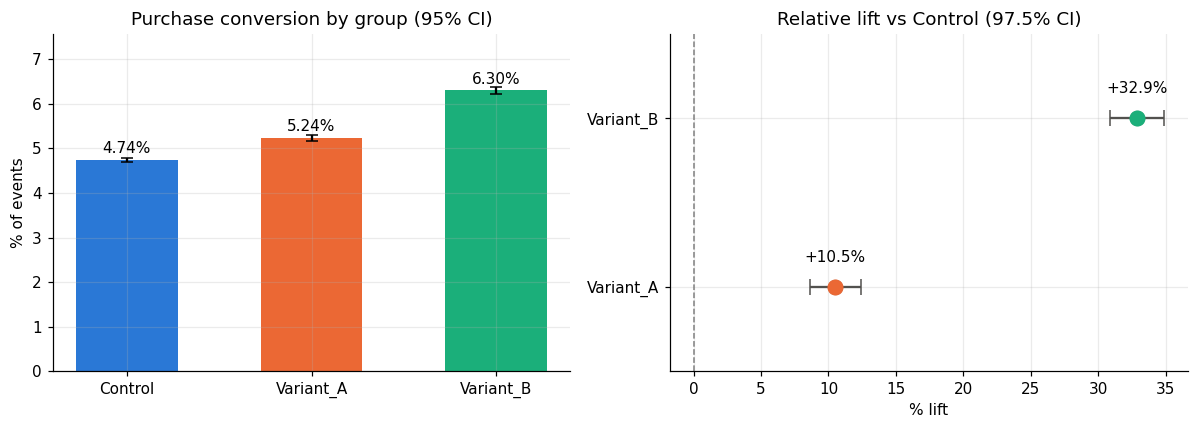

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
groups = summary.index
rates = summary.conversion * 100
err = 1.96 * np.sqrt(summary.conversion*(1-summary.conversion)/summary.events) * 100
ax[0].bar(groups, rates, yerr=err, capsize=4, width=.55,
          color=[COLORS[g] for g in groups])
for i, r in enumerate(rates): ax[0].text(i, r + .15, f'{r:.2f}%', ha='center')
ax[0].set_title('Purchase conversion by group (95% CI)'); ax[0].set_ylabel('% of events')
ax[0].set_ylim(0, rates.max()*1.2)

lift = conv['relative_lift_%']
ci_rel = (conv[['ci_low_pp','ci_high_pp']].div(conv.control*100, axis=0))*100
ax[1].errorbar(lift, range(2), xerr=[lift-ci_rel.ci_low_pp, ci_rel.ci_high_pp-lift],
               fmt='o', ms=9, capsize=5, color='#52514e')
for i, g in enumerate(lift.index):
    ax[1].scatter(lift[g], i, s=90, color=COLORS[g], zorder=3)
    ax[1].text(lift[g], i + .15, f'+{lift[g]:.1f}%', ha='center')
ax[1].axvline(0, color='grey', lw=1, ls='--')
ax[1].set_yticks(range(2)); ax[1].set_yticklabels(lift.index); ax[1].set_ylim(-.5, 1.5)
ax[1].set_title('Relative lift vs Control (97.5% CI)'); ax[1].set_xlabel('% lift')
plt.tight_layout(); plt.savefig(FIG + 'conversion_lift.png', bbox_inches='tight'); plt.show()

## 5. Secondary and guardrail metrics

In [10]:
# Add-to-cart (secondary) and bounce (guardrail: must not get worse)
print('Add-to-cart rate'); display(compare('add_cart'))
print('Bounce rate (guardrail)'); display(compare('bounce'))

Add-to-cart rate


,control,variant_rate,abs_diff_pp,ci_low_pp,ci_high_pp,relative_lift_%,p_value,significant
variant,,,,,,,,
Variant_A,0.1426,0.1422,-0.0369,-0.1794,0.1062,-0.2586,0.5629,False
Variant_B,0.1426,0.1408,-0.1786,-0.3208,-0.0357,-1.2522,0.0051,True


Bounce rate (guardrail)


,control,variant_rate,abs_diff_pp,ci_low_pp,ci_high_pp,relative_lift_%,p_value,significant
variant,,,,,,,,
Variant_A,0.0956,0.0950,-0.0570,-0.1766,0.0633,-0.5966,0.2872,False
Variant_B,0.0956,0.0929,-0.2670,-0.3858,-0.1474,-2.7923,0.0000,True


**Reading this:** Variant B cuts bounces, but its add-to-cart rate is slightly lower (-1.3% relative).
Because each metric is a share of all events, more purchase events mechanically leave a smaller share for other event types, so a small dip is expected when conversion rises.
It's worth watching, but it isn't a blocker.

In [11]:
# Net revenue per event: skewed, so use a bootstrap CI for the difference in means
rng = np.random.default_rng(42)
def boot_diff(a, b, n=500):
    a, b = a.to_numpy(), b.to_numpy()
    diffs = [rng.choice(a, len(a)).mean() - rng.choice(b, len(b)).mean() for _ in range(n)]
    return np.percentile(diffs, [1.25, 98.75])

rev = df[df.gross_revenue.notna() | (df.purchase==0)]   # drop purchases with unknown revenue
c = rev[rev.experiment_group=='Control'].revenue
rows = []
for g in ['Variant_A','Variant_B']:
    v = rev[rev.experiment_group==g].revenue
    lo, hi = boot_diff(v, c)
    rows.append({'variant': g, 'control_$': c.mean(), 'variant_$': v.mean(),
                 'lift_%': (v.mean()/c.mean()-1)*100, 'diff_ci_low': lo, 'diff_ci_high': hi,
                 'welch_p': stats.ttest_ind(v, c, equal_var=False).pvalue})
pd.DataFrame(rows).set_index('variant')

,control_$,variant_$,lift_%,diff_ci_low,diff_ci_high,welch_p
variant,,,,,,
Variant_A,3.8989,4.2755,9.6590,0.2587,0.4981,0.0000
Variant_B,3.8989,5.0726,30.1039,1.0593,1.2846,0.0000


In [12]:
# Refund rate among purchases (guardrail)
p = df[(df.purchase==1)]
ct = pd.crosstab(p.experiment_group, p.refund_flag)
print(f'Refund rate chi-square p = {stats.chi2_contingency(ct)[1]:.3f}')
p.groupby('experiment_group').refund_flag.mean()

Refund rate chi-square p = 0.881


experiment_group
Control     0.0293
Variant_A   0.0290
Variant_B   0.0298
Name: refund_flag, dtype: float64

## 6. Segment analysis: is the Variant B lift consistent?

A lift driven by a single segment is a red flag. Check Variant B vs Control by device and by traffic source.

experiment_group,Control,Variant_A,Variant_B,B_lift_%,A_lift_%
device_type,,,,,
desktop,0.0473,0.0528,0.0630,33.1032,11.6238
mobile,0.0474,0.0521,0.0634,33.6679,9.8938
tablet,0.0481,0.0533,0.0608,26.3916,10.9722
unknown,0.0485,0.0526,0.0593,22.0758,8.3927


experiment_group,Control,Variant_A,Variant_B,B_lift_%,A_lift_%
traffic_source,,,,,
Direct,0.0168,0.0229,0.0318,89.0754,36.3500
Email,0.0846,0.0901,0.1004,18.6449,6.4201
Organic,0.0168,0.0216,0.0326,93.9186,28.1369
Paid Search,0.0801,0.0846,0.0956,19.2440,5.5950
Social,0.0688,0.0741,0.0843,22.6666,7.7596


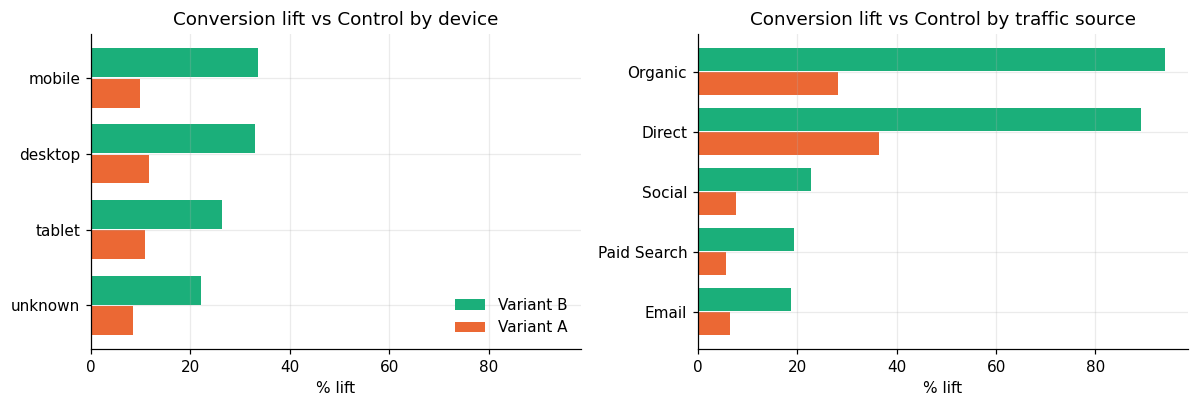

In [13]:
def seg_lift(col):
    t = df.groupby([col,'experiment_group']).purchase.mean().unstack()
    t['B_lift_%'] = (t.Variant_B/t.Control - 1)*100
    t['A_lift_%'] = (t.Variant_A/t.Control - 1)*100
    return t

dev, src = seg_lift('device_type'), seg_lift('traffic_source')
display(dev); display(src)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for a, t, title in [(ax[0], dev, 'by device'), (ax[1], src, 'by traffic source')]:
    t = t.sort_values('B_lift_%')
    y = np.arange(len(t))
    a.barh(y + .2, t['B_lift_%'], height=.38, color=COLORS['Variant_B'], label='Variant B')
    a.barh(y - .2, t['A_lift_%'], height=.38, color=COLORS['Variant_A'], label='Variant A')
    a.set_yticks(y); a.set_yticklabels(t.index); a.axvline(0, color='grey', lw=1)
    a.set_title(f'Conversion lift vs Control {title}'); a.set_xlabel('% lift')
ax[0].legend(loc='lower right', frameon=False)
plt.tight_layout(); plt.savefig(FIG + 'segment_lift.png', bbox_inches='tight'); plt.show()

## 7. Was the test big enough? (power / MDE)

Minimum detectable effect: the smallest relative lift this sample could reliably detect (80% power, α = 0.025).

In [14]:
base = summary.loc['Control','conversion']
n_c, n_v = summary.loc['Control','events'], summary.loc['Variant_A','events']
es = NormalIndPower().solve_power(nobs1=n_v, ratio=n_c/n_v, alpha=ALPHA, power=.8)
# convert Cohen's h back to a conversion rate
mde_rate = np.sin(np.arcsin(np.sqrt(base)) + es/2)**2
print(f'Baseline conversion: {base:.2%}')
print(f'MDE: {mde_rate:.2%}  (relative lift of {(mde_rate/base-1):.1%})')
print('Observed lifts:', conv['relative_lift_%'].round(1).to_dict())

Baseline conversion: 4.74%
MDE: 4.86%  (relative lift of 2.5%)
Observed lifts: {'Variant_A': 10.5, 'Variant_B': 32.9}


## 8. Recommendation

See the summary printed below. In plain terms:

- **Ship Variant B.** Conversion goes from 4.74% to 6.30% (+33% relative) and net revenue per event rises ~30%. The lift holds across every device and traffic source, bounce rate falls, and refund rate and order value hold steady.
- **Variant A** also beats control (+10.5%), but B is about 3x better.
- The test was well powered: it could detect a lift as small as ~2.5%, far below what was observed.
- **Caveats:** assignment was per event, not per user, so one customer could see several variants. Before a full rollout, run a short user-level confirmation test (or a staged rollout) and track revenue per user.

In [15]:
b, a = conv.loc['Variant_B'], conv.loc['Variant_A']
print(f"Variant B: conversion {b.control:.2%} -> {b.variant_rate:.2%}  (+{b['relative_lift_%']:.1f}%, p{'<1e-100' if b.p_value < 1e-100 else f'={b.p_value:.1e}'})")
print(f"Variant A: conversion {a.control:.2%} -> {a.variant_rate:.2%}  (+{a['relative_lift_%']:.1f}%, p={a.p_value:.1e})")

Variant B: conversion 4.74% -> 6.30%  (+32.9%, p<1e-100)
Variant A: conversion 4.74% -> 5.24%  (+10.5%, p=5.8e-37)
